In [124]:
import Encoder
import Decoder
import numpy as np
import utills as ut
import cv2
import matplotlib.pyplot as plt

**Important Parameters**

In [125]:
block_sizes = [4, 8, 16]
coding_techniques = ['arithmetic', 'huffman']
search_ranges = [4, 8, 16]
AVC_PARAMS = {
    (4, 'intra'): (-256, -901, 8264, 5652),
    (4, 'inter'): (-192, -563, 5440, 9907),

    (8, 'intra'): (-56, -127, 3364, 6898),
    (8, 'inter'): (-28, -50, 2070, 11260),

    (16, 'intra'): (-14, -32, 1682, 6898),
    (16, 'inter'): (-7, -13, 1035, 11260),
}

HVS_PARAMS = {
    (4, 'intra'): (2048, 3768, -6164, 15647),
    (4, 'inter'): (1536, 2601, -4209, 14582),

    (8, 'intra'): (619, 1277, -4904, 20249),
    (8, 'inter'): (497, 873, -3587, 18240),

    (16, 'intra'): (171, 369, -3039, 23826),
    (16, 'inter'): (136, 236, -2125, 20542),
}


**Generate the required quantization table in according to sony's patent**

In [126]:
def generate_qmatrix(size, params):
    a, b, c, d = params
    Q = np.zeros((size, size), dtype=np.int32)
    for x in range(size):
        for y in range(size):
            value = (
                a * (x**2 + y**2) + b * (x * y) + c * (x + y) + d + 512
            ) >> 10
            Q[x, y] = max(1, value)
    return Q


In [127]:
num_frames, h, w = 30, 64, 64
video_data = ut.generate_moving_square(num_frames=num_frames, h=h, w=w)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter('test_video.mp4', fourcc, 30, (w, h), isColor=False)

for frame in video_data:
    writer.write(frame)
writer.release()
print("Synthetic video saved successfully.")

Synthetic video saved successfully.


In [128]:
def run_experiment(block_size, q_type='hvs', coding='arithmetic', search_range=4, strength=1):
    if q_type == 'hvs':
        intra_q = generate_qmatrix(block_size, HVS_PARAMS[(block_size, 'intra')])
        inter_q = generate_qmatrix(block_size, HVS_PARAMS[(block_size, 'inter')])
    else:
        intra_q = generate_qmatrix(block_size, AVC_PARAMS[(block_size, 'intra')])
        inter_q = generate_qmatrix(block_size, AVC_PARAMS[(block_size, 'inter')])

    enc = Encoder.Encoder('test_video.mp4', block_size, strength*intra_q, strength*inter_q, coding, search_range)
    results = enc.encode()
    
    if coding == 'arithmetic':
        bits, metadata, mv_bits, _, frames = results
        total_bits = len(bits) + len(mv_bits)
        dec = Decoder.Decoder(
            bits,
            block_size,
            intra_q,
            inter_q,
            coding,
            frames[0].shape,
            len(frames),
            motion_vectors_all=None,
            frequencies=metadata['frequencies'],
            motion_vector_bits=mv_bits,
            motion_vector_metadata=metadata,
        )
    else: 
        bits, codec, mv_bits, mv_codec, mvs, frames, _, _ = results
        total_bits = (len(bits) + len(mv_bits)) * 8 
        dec = Decoder.Decoder(
            bits,
            block_size,
            intra_q,
            inter_q,
            coding,
            frames[0].shape,
            len(frames),
            motion_vectors_all=mvs,
            codec=codec,
            motion_vector_bits=mv_bits,
            motion_vector_codec=mv_codec,
        )
        
    reconstructed = dec.decode()
    mse_val = ut.mse(np.array(frames), np.array(reconstructed))
    psnr_val = ut.psnr(np.array(frames), np.array(reconstructed))
    comp_ratio = ut.compression_ratio(frames, total_bits)
    return mse_val,comp_ratio, psnr_val


**Changing Block size**

In [129]:
block_data = {'size': [], 'mse': [], 'ratio': [], 'psnr': []}
for block_size in block_sizes:
    mse, ratio, psnr = run_experiment(block_size, 'hvs', 'arithmetic', 4)
    block_data['size'].append(block_size)
    block_data['mse'].append(mse)
    block_data['ratio'].append(ratio)
    block_data['psnr'].append(psnr)
    print(f"Block Size: {block_size}, MSE: {mse:.2f}, Ratio: {ratio:.2f}, PSNR: {psnr:.2f} dB")


Block Size: 4, MSE: 44.49, Ratio: 98.76, PSNR: 31.65 dB
Block Size: 8, MSE: 317.02, Ratio: 112.10, PSNR: 23.12 dB
Block Size: 16, MSE: 2042.57, Ratio: 85.33, PSNR: 15.03 dB


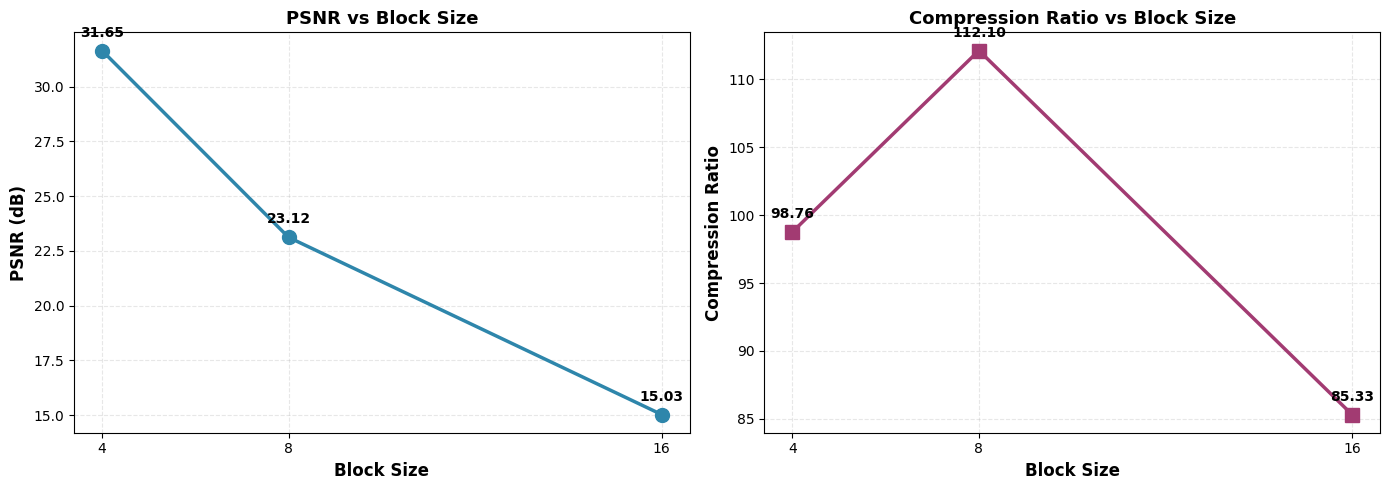

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(block_data['size'], block_data['psnr'], 'o-', linewidth=2.5, markersize=10, color='#2E86AB')
ax1.set_xlabel('Block Size', fontsize=12, fontweight='bold')
ax1.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax1.set_title('PSNR vs Block Size', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(block_data['size'])
for i, (size, psnr) in enumerate(zip(block_data['size'], block_data['psnr'])):
    ax1.annotate(f'{psnr:.2f}', xy=(size, psnr), xytext=(0, 10), textcoords='offset points', 
                ha='center', fontsize=10, fontweight='bold')

ax2.plot(block_data['size'], block_data['ratio'], 's-', linewidth=2.5, markersize=10, color='#A23B72')
ax2.set_xlabel('Block Size', fontsize=12, fontweight='bold')
ax2.set_ylabel('Compression Ratio', fontsize=12, fontweight='bold')
ax2.set_title('Compression Ratio vs Block Size', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks(block_data['size'])
for i, (size, ratio) in enumerate(zip(block_data['size'], block_data['ratio'])):
    ax2.annotate(f'{ratio:.2f}', xy=(size, ratio), xytext=(0, 10), textcoords='offset points', 
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/block_size_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


**Changing Coding Method**

In [131]:
coding_data = {'method': [], 'mse': [], 'ratio': [], 'psnr': []}
for method in ['huffman', 'arithmetic']:
    mse, ratio, psnr = run_experiment(8, 'hvs', method, 4)
    coding_data['method'].append(method.upper())
    coding_data['mse'].append(mse)
    coding_data['ratio'].append(ratio)
    coding_data['psnr'].append(psnr)
    print(f"[{method.upper()}] MSE: {mse:.2f}, Ratio: {ratio:.2f}, PSNR: {psnr:.2f} dB")


[HUFFMAN] MSE: 317.02, Ratio: 103.35, PSNR: 23.12 dB
[ARITHMETIC] MSE: 317.02, Ratio: 112.10, PSNR: 23.12 dB


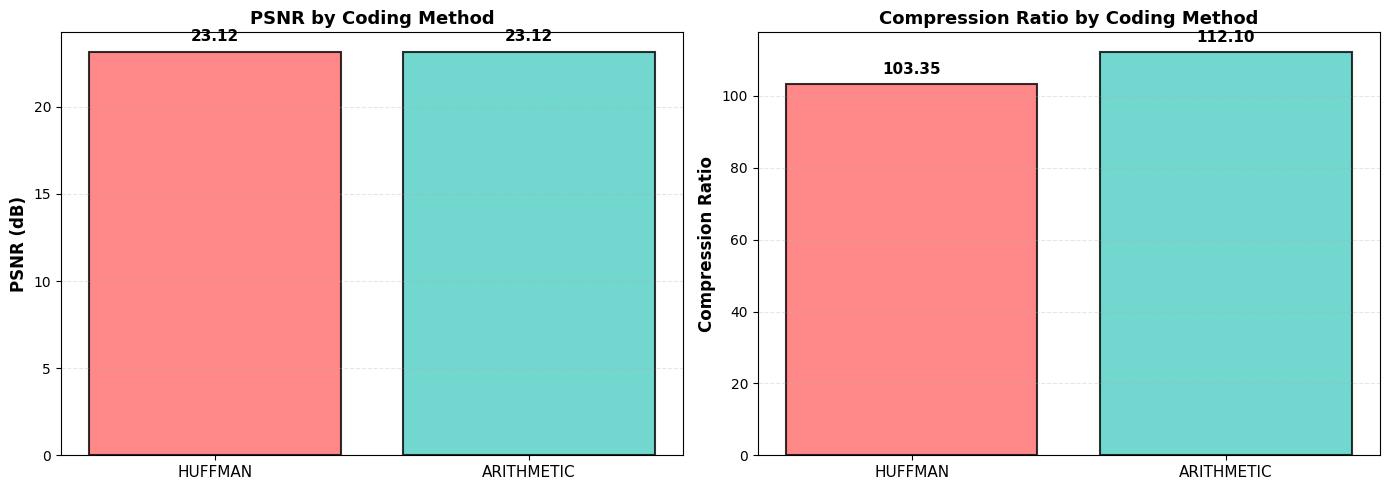

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#FF6B6B', '#4ECDC4']
x_pos = range(len(coding_data['method']))

bars1 = ax1.bar(x_pos, coding_data['psnr'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax1.set_title('PSNR by Coding Method', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(coding_data['method'], fontsize=11)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
for i, (bar, val) in enumerate(zip(bars1, coding_data['psnr'])):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

bars2 = ax2.bar(x_pos, coding_data['ratio'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Compression Ratio', fontsize=12, fontweight='bold')
ax2.set_title('Compression Ratio by Coding Method', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(coding_data['method'], fontsize=11)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
for i, (bar, val) in enumerate(zip(bars2, coding_data['ratio'])):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/coding_method_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


**Quantization Table for intra and inter compression**

In [133]:
quantization_data = {'method': [], 'mse': [], 'ratio': [], 'psnr': []}
for q_tech in ['avc', 'hvs']:
    mse, ratio, psnr = run_experiment(8, q_tech, 'arithmetic', 4)
    quantization_data['method'].append(q_tech.upper())
    quantization_data['mse'].append(mse)
    quantization_data['ratio'].append(ratio)
    quantization_data['psnr'].append(psnr)
    print(f"[{q_tech.upper()} Matrix] MSE: {mse:.2f}, Ratio: {ratio:.2f}, PSNR: {psnr:.2f} dB")


[AVC Matrix] MSE: 320.14, Ratio: 113.41, PSNR: 23.08 dB
[HVS Matrix] MSE: 317.02, Ratio: 112.10, PSNR: 23.12 dB


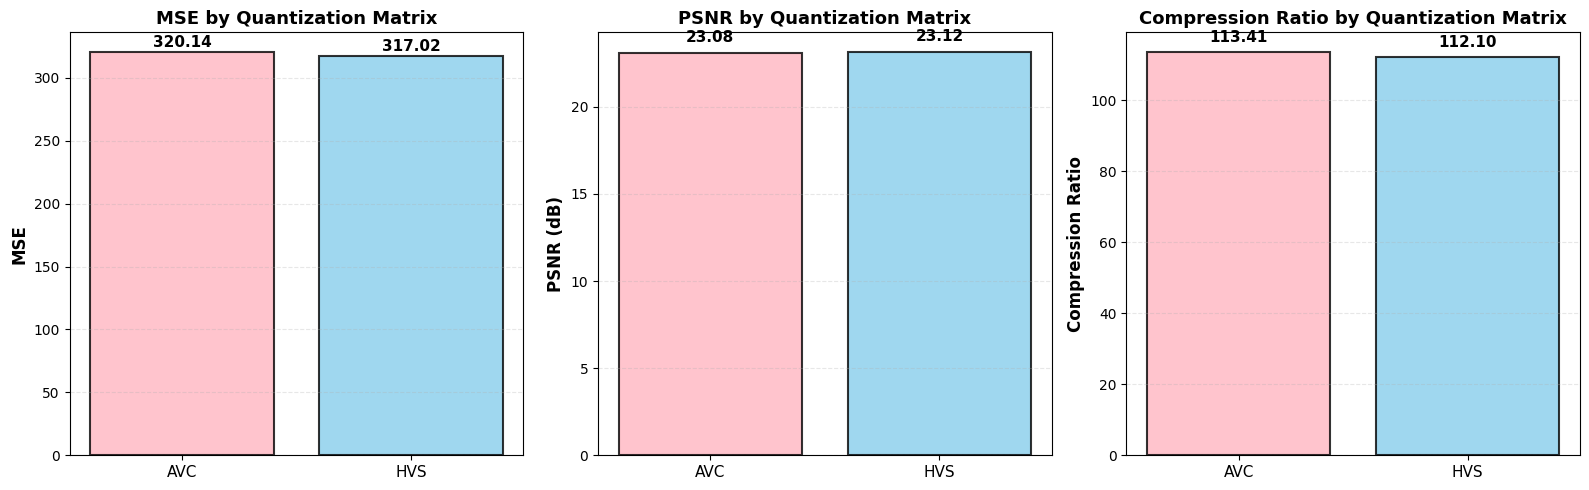

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#FFB6C1', '#87CEEB']
x_pos = range(len(quantization_data['method']))

bars1 = ax1.bar(x_pos, quantization_data['mse'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('MSE', fontsize=12, fontweight='bold')
ax1.set_title('MSE by Quantization Matrix', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(quantization_data['method'], fontsize=11)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
for bar, val in zip(bars1, quantization_data['mse']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

bars2 = ax2.bar(x_pos, quantization_data['psnr'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax2.set_title('PSNR by Quantization Matrix', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(quantization_data['method'], fontsize=11)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
for bar, val in zip(bars2, quantization_data['psnr']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

bars3 = ax3.bar(x_pos, quantization_data['ratio'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Compression Ratio', fontsize=12, fontweight='bold')
ax3.set_title('Compression Ratio by Quantization Matrix', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(quantization_data['method'], fontsize=11)
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')
for bar, val in zip(bars3, quantization_data['ratio']):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/quantization_matrix_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


In [135]:
search_range_data = {'range': [], 'mse': [], 'ratio': [], 'psnr': []}
for search_range in search_ranges:
    mse, ratio, psnr = run_experiment(8, 'hvs', 'arithmetic', search_range)
    search_range_data['range'].append(search_range)
    search_range_data['mse'].append(mse)
    search_range_data['ratio'].append(ratio)
    search_range_data['psnr'].append(psnr)
    print(f"[{search_range} Search Range] MSE: {mse:.2f}, Ratio: {ratio:.2f}, PSNR: {psnr:.2f} dB")


[4 Search Range] MSE: 317.02, Ratio: 112.10, PSNR: 23.12 dB
[8 Search Range] MSE: 76.28, Ratio: 120.04, PSNR: 29.31 dB
[16 Search Range] MSE: 75.92, Ratio: 96.34, PSNR: 29.33 dB


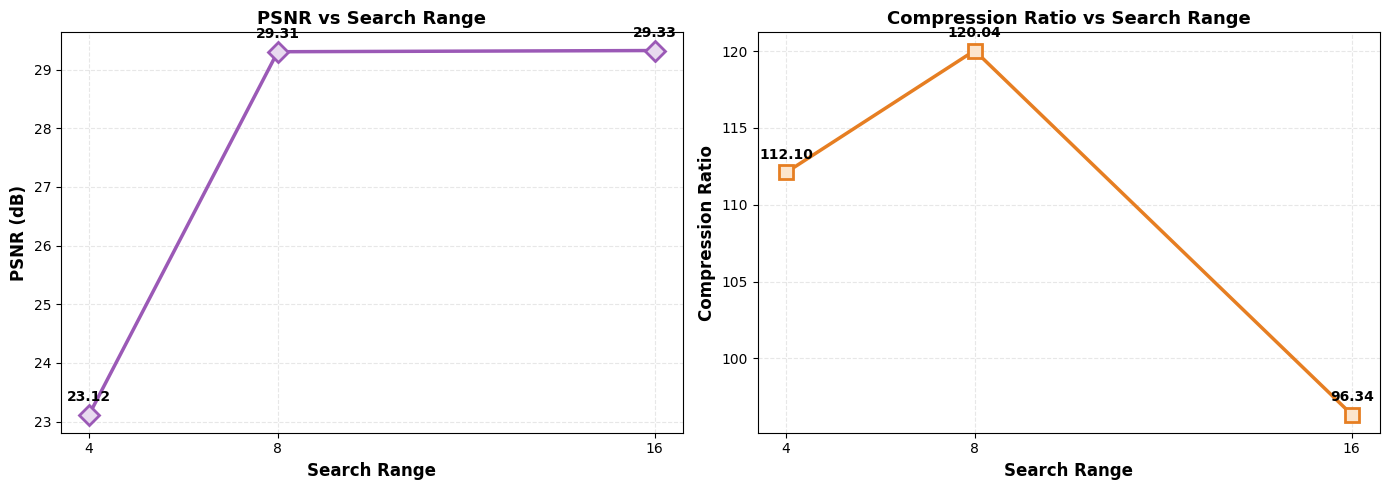

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(search_range_data['range'], search_range_data['psnr'], 'D-', linewidth=2.5, markersize=10, 
         color='#9B59B6', markerfacecolor='#E8DAEF', markeredgewidth=2)
ax1.set_xlabel('Search Range', fontsize=12, fontweight='bold')
ax1.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax1.set_title('PSNR vs Search Range', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(search_range_data['range'])
for sr, psnr in zip(search_range_data['range'], search_range_data['psnr']):
    ax1.annotate(f'{psnr:.2f}', xy=(sr, psnr), xytext=(0, 10), textcoords='offset points', 
                ha='center', fontsize=10, fontweight='bold')

ax2.plot(search_range_data['range'], search_range_data['ratio'], 's-', linewidth=2.5, markersize=10, 
         color='#E67E22', markerfacecolor='#FCE5CD', markeredgewidth=2)
ax2.set_xlabel('Search Range', fontsize=12, fontweight='bold')
ax2.set_ylabel('Compression Ratio', fontsize=12, fontweight='bold')
ax2.set_title('Compression Ratio vs Search Range', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks(search_range_data['range'])
for sr, ratio in zip(search_range_data['range'], search_range_data['ratio']):
    ax2.annotate(f'{ratio:.2f}', xy=(sr, ratio), xytext=(0, 10), textcoords='offset points', 
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/search_range_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


**Varying quantization Strength**

In [137]:
strengths = [0.5, 1, 2]
strength_data = {'strength': [], 'mse': [], 'ratio': [], 'psnr': []}
for strength in strengths:
    mse, ratio, psnr = run_experiment(8, 'hvs', 'arithmetic', 8, strength=strength)
    strength_data['strength'].append(strength)
    strength_data['mse'].append(mse)
    strength_data['ratio'].append(ratio)
    strength_data['psnr'].append(psnr)
    print(f"[Strength {strength}] MSE: {mse:.2f}, Ratio: {ratio:.2f}, PSNR: {psnr:.2f} dB")


[Strength 0.5] MSE: 76.65, Ratio: 109.74, PSNR: 29.29 dB
[Strength 1] MSE: 76.28, Ratio: 120.04, PSNR: 29.31 dB
[Strength 2] MSE: 406.60, Ratio: 131.79, PSNR: 22.04 dB


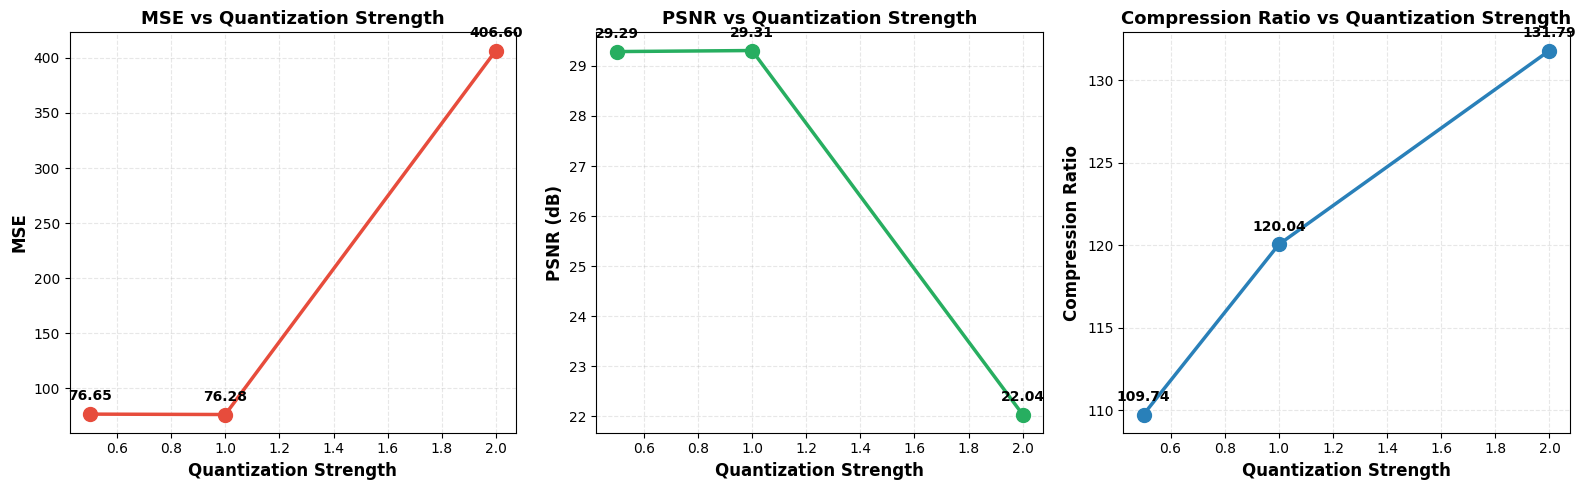

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

ax1.plot(strength_data['strength'], strength_data['mse'], 'o-', linewidth=2.5, markersize=10, color='#E74C3C')
ax1.set_xlabel('Quantization Strength', fontsize=12, fontweight='bold')
ax1.set_ylabel('MSE', fontsize=12, fontweight='bold')
ax1.set_title('MSE vs Quantization Strength', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
for strength, mse in zip(strength_data['strength'], strength_data['mse']):
    ax1.annotate(f'{mse:.2f}', xy=(strength, mse), xytext=(0, 10), textcoords='offset points', 
                ha='center', fontsize=10, fontweight='bold')

ax2.plot(strength_data['strength'], strength_data['psnr'], 'o-', linewidth=2.5, markersize=10, color='#27AE60')
ax2.set_xlabel('Quantization Strength', fontsize=12, fontweight='bold')
ax2.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax2.set_title('PSNR vs Quantization Strength', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
for strength, psnr in zip(strength_data['strength'], strength_data['psnr']):
    ax2.annotate(f'{psnr:.2f}', xy=(strength, psnr), xytext=(0, 10), textcoords='offset points', 
                ha='center', fontsize=10, fontweight='bold')

ax3.plot(strength_data['strength'], strength_data['ratio'], 'o-', linewidth=2.5, markersize=10, color='#2980B9')
ax3.set_xlabel('Quantization Strength', fontsize=12, fontweight='bold')
ax3.set_ylabel('Compression Ratio', fontsize=12, fontweight='bold')
ax3.set_title('Compression Ratio vs Quantization Strength', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
for strength, ratio in zip(strength_data['strength'], strength_data['ratio']):
    ax3.annotate(f'{ratio:.2f}', xy=(strength, ratio), xytext=(0, 10), textcoords='offset points', 
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/quantization_strength_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


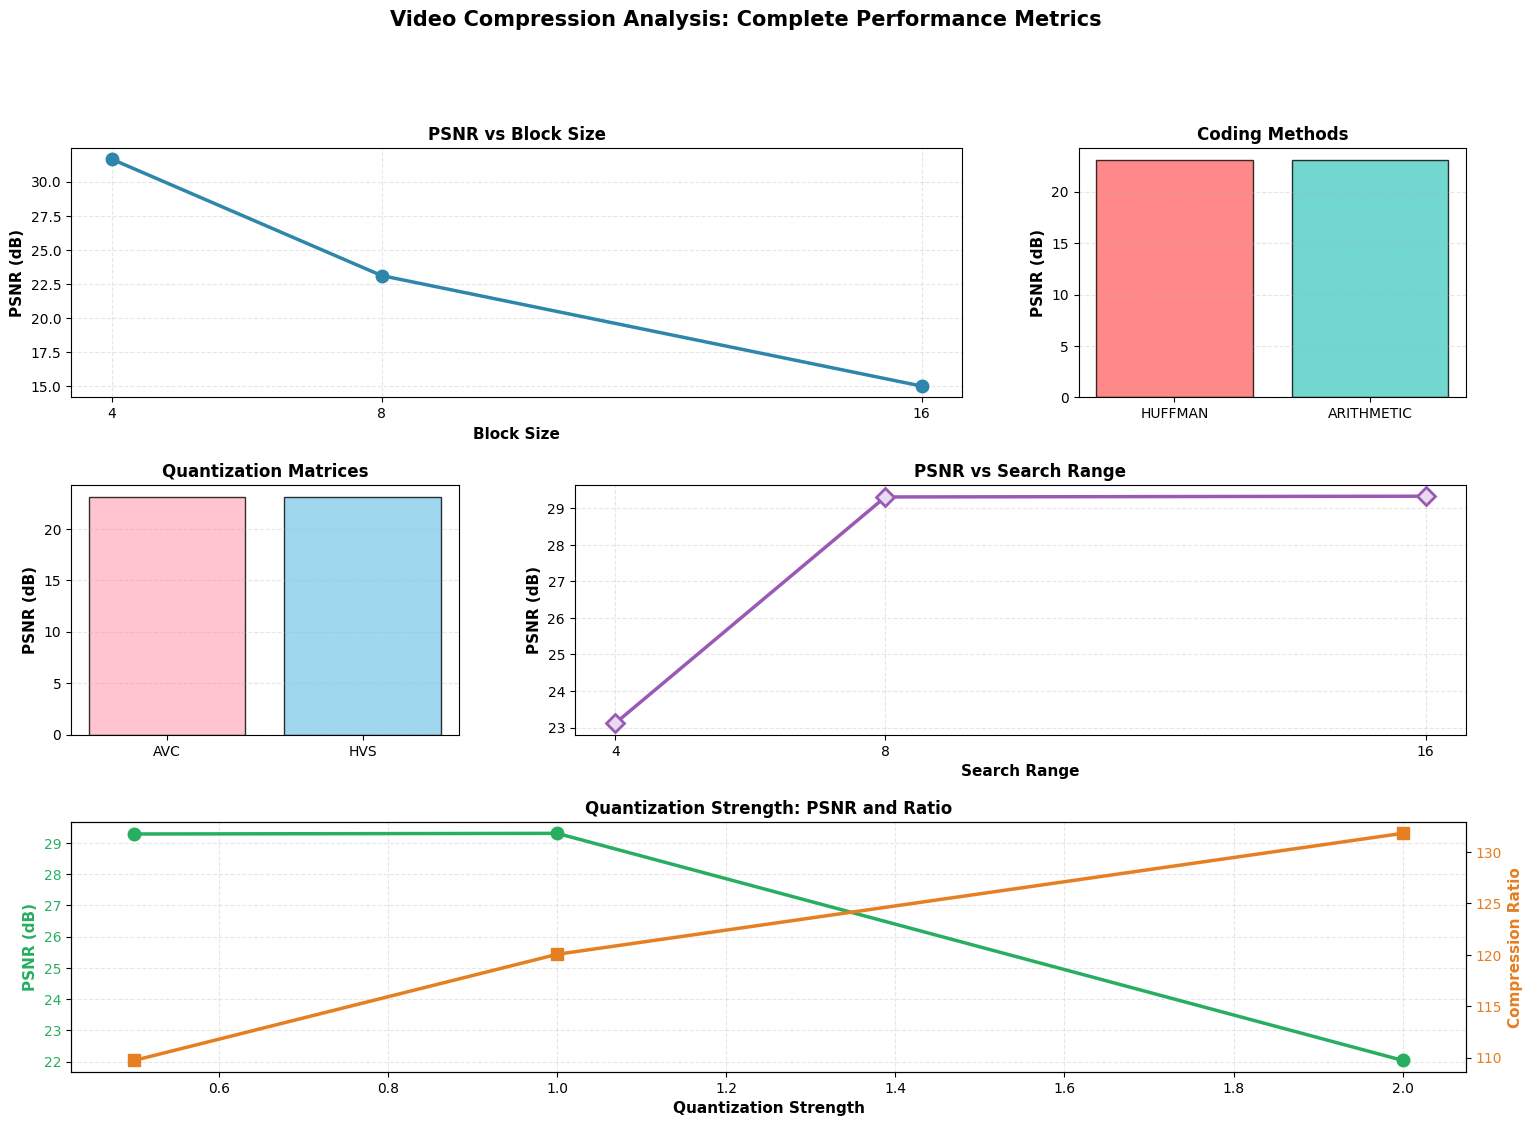

In [ ]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(block_data['size'], block_data['psnr'], 'o-', linewidth=2.5, markersize=9, color='#2E86AB', label='Block Size')
ax1.set_xlabel('Block Size', fontsize=11, fontweight='bold')
ax1.set_ylabel('PSNR (dB)', fontsize=11, fontweight='bold')
ax1.set_title('PSNR vs Block Size', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(block_data['size'])

ax2 = fig.add_subplot(gs[0, 2])
colors_coding = ['#FF6B6B', '#4ECDC4']
ax2.bar(range(len(coding_data['method'])), coding_data['psnr'], color=colors_coding, alpha=0.8, edgecolor='black')
ax2.set_ylabel('PSNR (dB)', fontsize=11, fontweight='bold')
ax2.set_title('Coding Methods', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(coding_data['method'])))
ax2.set_xticklabels(coding_data['method'], fontsize=10)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

ax3 = fig.add_subplot(gs[1, 0])
colors_quant = ['#FFB6C1', '#87CEEB']
ax3.bar(range(len(quantization_data['method'])), quantization_data['psnr'], color=colors_quant, alpha=0.8, edgecolor='black')
ax3.set_ylabel('PSNR (dB)', fontsize=11, fontweight='bold')
ax3.set_title('Quantization Matrices', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(quantization_data['method'])))
ax3.set_xticklabels(quantization_data['method'], fontsize=10)
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

ax4 = fig.add_subplot(gs[1, 1:])
ax4.plot(search_range_data['range'], search_range_data['psnr'], 'D-', linewidth=2.5, markersize=9, 
         color='#9B59B6', markerfacecolor='#E8DAEF', markeredgewidth=2)
ax4.set_xlabel('Search Range', fontsize=11, fontweight='bold')
ax4.set_ylabel('PSNR (dB)', fontsize=11, fontweight='bold')
ax4.set_title('PSNR vs Search Range', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xticks(search_range_data['range'])

ax5 = fig.add_subplot(gs[2, :])
ax5.plot(strength_data['strength'], strength_data['psnr'], 'o-', linewidth=2.5, markersize=9, 
         color='#27AE60', label='PSNR')
ax5_ratio = ax5.twinx()
ax5_ratio.plot(strength_data['strength'], strength_data['ratio'], 's-', linewidth=2.5, markersize=9, 
              color='#E67E22', label='Ratio')
ax5.set_xlabel('Quantization Strength', fontsize=11, fontweight='bold')
ax5.set_ylabel('PSNR (dB)', fontsize=11, fontweight='bold', color='#27AE60')
ax5_ratio.set_ylabel('Compression Ratio', fontsize=11, fontweight='bold', color='#E67E22')
ax5.set_title('Quantization Strength: PSNR and Ratio', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.tick_params(axis='y', labelcolor='#27AE60')
ax5_ratio.tick_params(axis='y', labelcolor='#E67E22')

fig.suptitle('Video Compression Analysis: Complete Performance Metrics', fontsize=15, fontweight='bold', y=0.995)
plt.savefig('figures/comprehensive_video_compression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
